# HOMEWORK 14

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [19]:
import seaborn as sns
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from numpy.random import seed
from tensorflow.keras import Sequential, layers, activations, losses, metrics, optimizers, regularizers, callbacks
from tensorflow.random import set_seed
from collections import Counter
from sklearn.metrics import confusion_matrix

## Reproducibility

In [6]:
# Set the seeds for reproducibility
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [15, 10]

seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

## Callbacks

In [7]:
early_stopping_cb = callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor="val_loss",
)

lr_optimizer_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

## Visualization

In [8]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


## Distribution Analysis

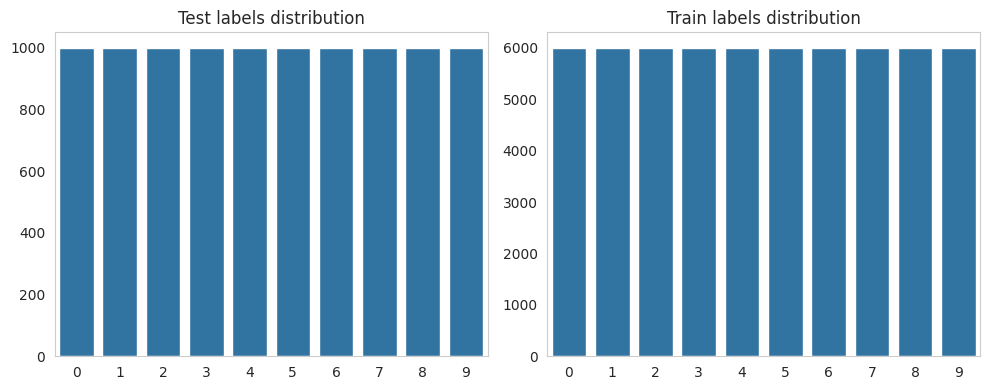

In [10]:
test_cnt = Counter(y_test)
train_cnt = Counter(y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(test_cnt, ax=axes[0])
axes[0].set_title('Test labels distribution')
axes[0].grid(False)

sns.barplot(train_cnt, ax=axes[1])
axes[1].set_title('Train labels distribution')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## Dataset Visualization

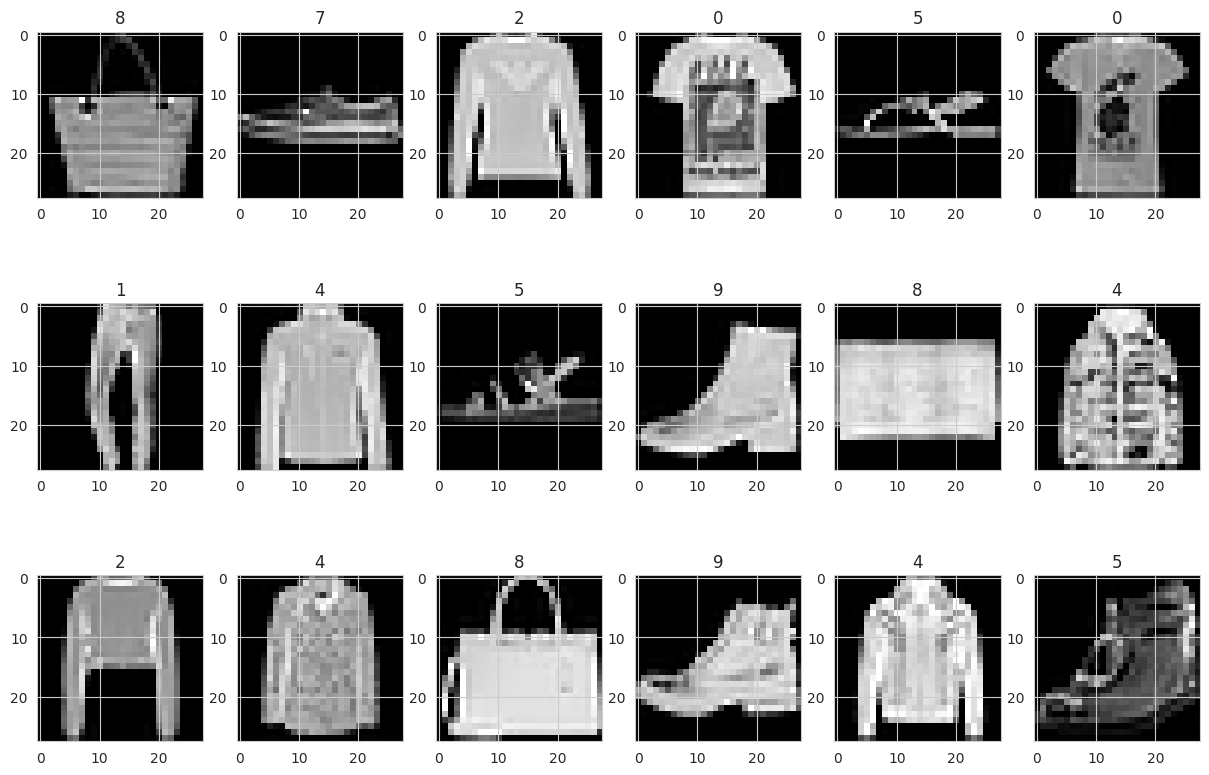

In [11]:
## Let's visualise some random samples.
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [12]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test,  num_classes)

In [13]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust
model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same'),
    layers.Flatten(),
    layers.Dense(128),
    layers.Dense(10, activation="softmax")
])
model.summary()

I0000 00:00:1774340919.366094      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [14]:
epochs = 25
batch_size = 128

model.compile(loss=losses.categorical_crossentropy,  optimizer='adam', metrics=["accuracy"])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test)
                    )

Epoch 1/25


I0000 00:00:1774340922.670991     127 service.cc:152] XLA service 0x7c3d90002700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774340922.671028     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774340922.991539     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 44/469 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5130 - loss: 2.1188

I0000 00:00:1774340924.670950     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7828 - loss: 0.7658 - val_accuracy: 0.8757 - val_loss: 0.3545
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8950 - loss: 0.2977 - val_accuracy: 0.8825 - val_loss: 0.3342
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9115 - loss: 0.2507 - val_accuracy: 0.8849 - val_loss: 0.3262
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9221 - loss: 0.2199 - val_accuracy: 0.8885 - val_loss: 0.3215
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9314 - loss: 0.1955 - val_accuracy: 0.8924 - val_loss: 0.3210
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9382 - loss: 0.1765 - val_accuracy: 0.8909 - val_loss: 0.3325
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9441 - loss: 0.1593 - val_accuracy: 0.8911 - val_loss: 0.3495
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9498 - loss: 0.1434 - val_accuracy: 0.8921 - val_

## Draw history

Train Acc      0.9839500188827515
Validation Acc 0.8876000046730042


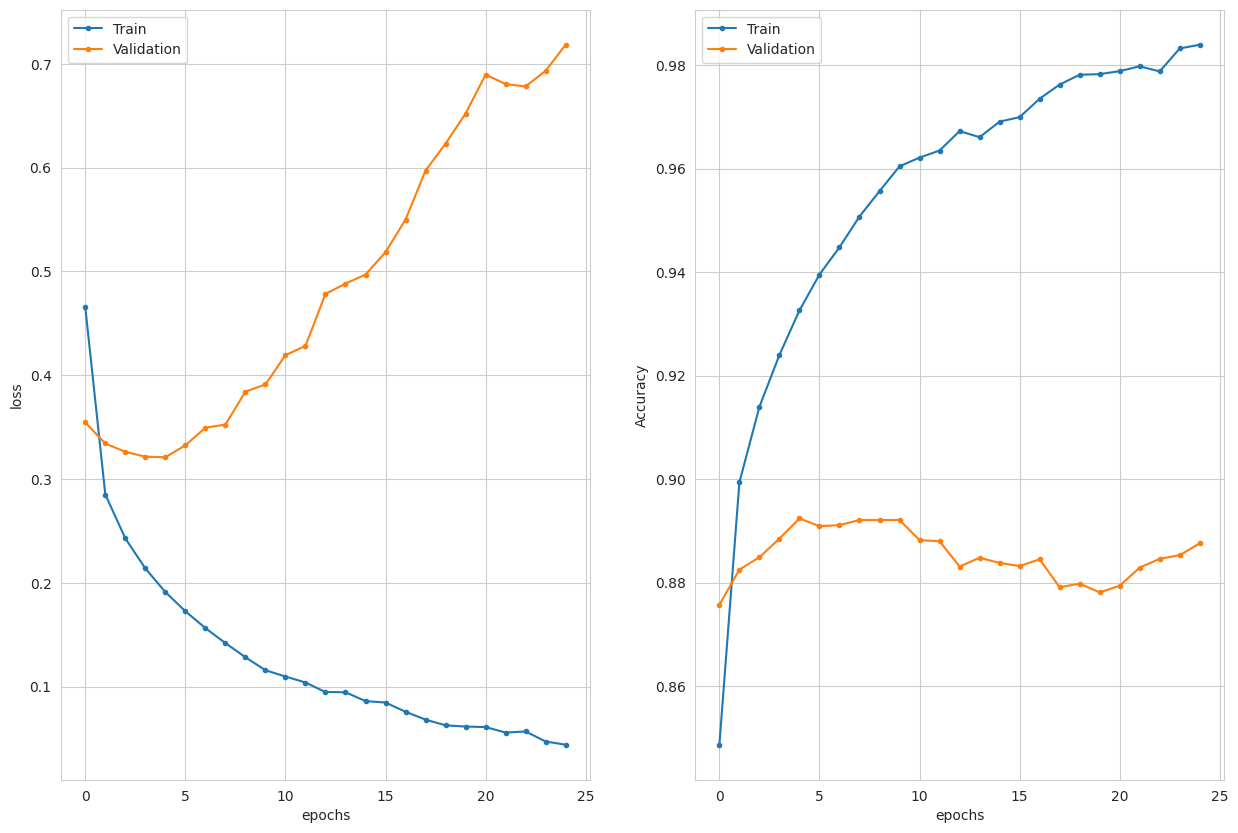

In [15]:
plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

### Questions

* Q: What have you done in order to improve the performance?
* A: Weight Decay, DropOut, BatchNorm, L2-Regularization, LeakyRelu, MaxPooling2D and GlobalAveragePooling2D instead Flatten, EarlyStoppinng and ReduceLROnPlateau ( tune Learning Rate )
* Q: Have you tried configurations that did not work out?
* A: Yes. I try to change number of layers, number of neurons, optimizers ( SGD, Adam, Nadam ), batch size ( from 32 to 512 )

## Regularize Model

In [16]:
model = Sequential([
    # Input Layer
    layers.Input(shape=(28, 28, 1)),
    # Data Augmentation
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),

    layers.Conv2D(16, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Conv2D(16, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation=activations.leaky_relu, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation=activations.leaky_relu, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    # Output Layer
    layers.Dense(10, activation=activations.softmax) #  10 classes = 10 output neurons
])

## Training

In [17]:
epochs = 100
batch_size = 128

model.compile(loss=losses.categorical_crossentropy,
              optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
              metrics=["accuracy",
                       metrics.F1Score,
                       metrics.Recall,
                       metrics.Precision])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    callbacks=[
                        early_stopping_cb,
                        lr_optimizer_cb
                    ]
                    )

Epoch 1/100


E0000 00:00:1774340981.731360      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.5092 - f1_score: 0.5069 - loss: 1.5414 - precision: 0.6306 - recall: 0.3989 - val_accuracy: 0.5637 - val_f1_score: 0.5503 - val_loss: 1.2537 - val_precision: 0.7434 - val_recall: 0.4300 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7496 - f1_score: 0.7449 - loss: 0.7254 - precision: 0.8345 - recall: 0.6685 - val_accuracy: 0.8155 - val_f1_score: 0.8030 - val_loss: 0.5454 - val_precision: 0.8533 - val_recall: 0.7793 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7991 - f1_score: 0.7955 - loss: 0.6119 - precision: 0.8558 - recall: 0.7386 - val_accuracy: 0.8251 - val_f1_score: 0.8203 - val_loss: 0.5347 - val_precision: 0.8571 - val_recall: 0.7995 - learning_rate: 0.0010
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8230 - f1_score: 0.8205 - loss: 0.5578 - precision: 0.8704 - recall: 0.7743 - val_accuracy: 0.8448 - val_f

## Draw History

Train Acc      0.9227166771888733
Validation Acc 0.9251000285148621


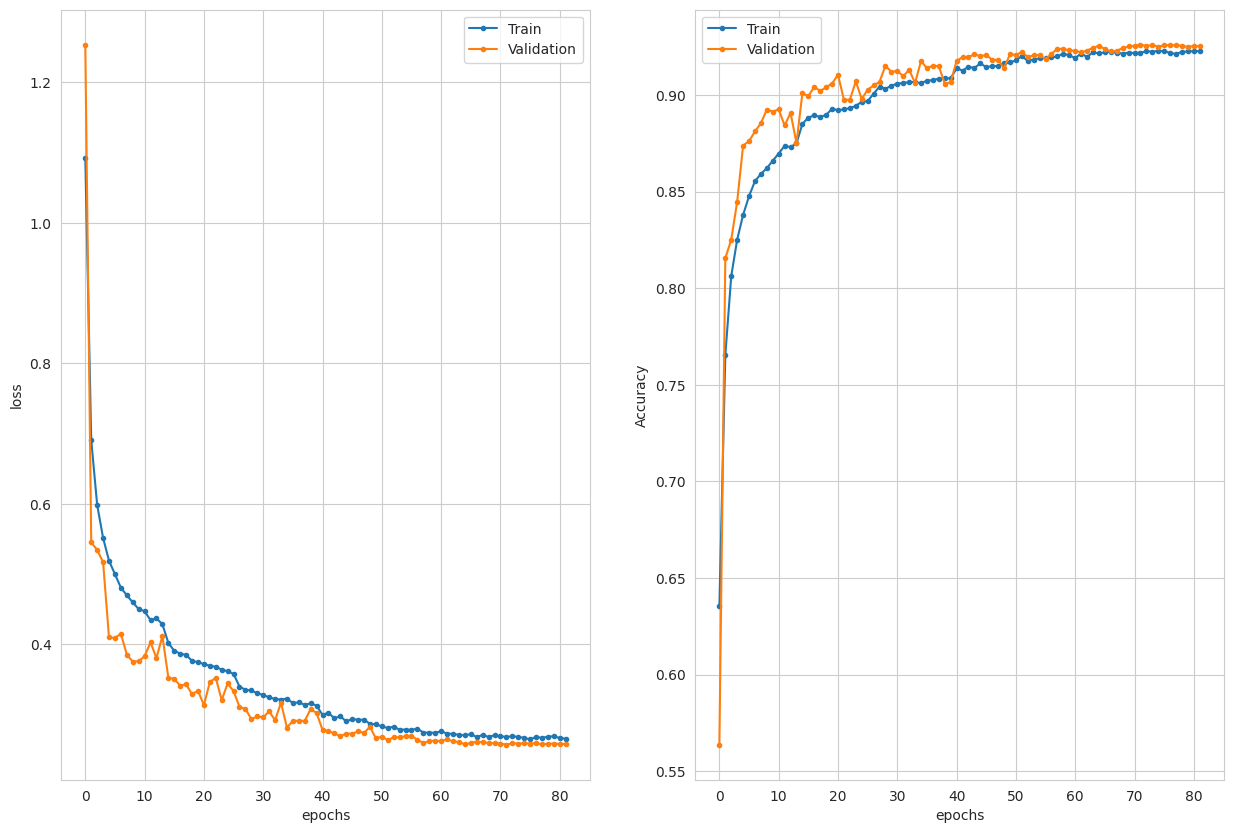

In [18]:
plot_history(history)

## Draw Conf Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


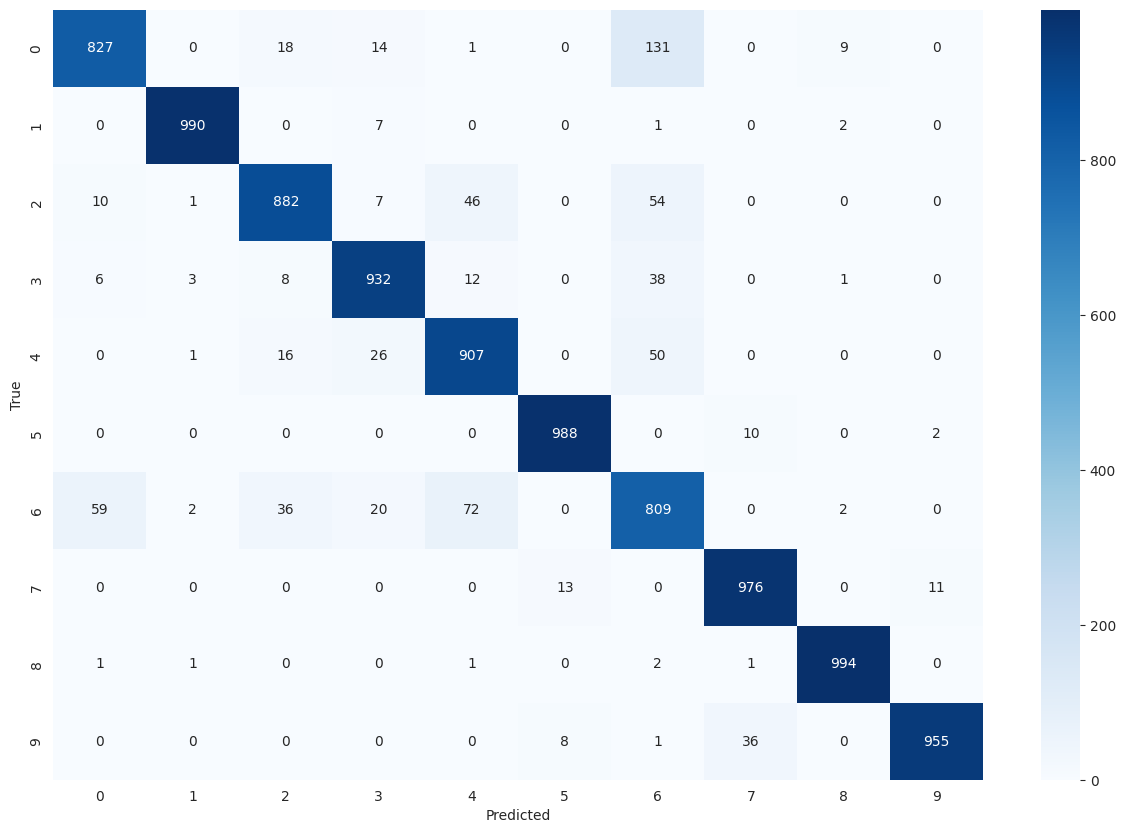

In [20]:
y_prob = model.predict(x_test)

y_pred = np.argmax(y_prob, axis=1)         # (N,) predicted class ids
y_true = np.argmax(y_test, axis=1)         # (N,) true class ids (since y_test is one-hot)

conf_mtx = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_mtx, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Results
- Max Epoch **82**
- Learning Rate : 3.9063e-06
- accuracy: **0.9226** - f1_score: 0.9224 - loss: **0.2628** - precision: 0.9344 - recall: 0.9112
- val_accuracy: **0.9251** - val_f1_score: 0.9255 - val_loss: **0.2586** - val_precision: 0.9308 - val_recall: 0.9182